In [ ]:
import os
import numpy as np
import random
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (Input, TimeDistributed, Conv1D, Dropout, Flatten,
                                     Dense, LayerNormalization, Layer, GlobalAveragePooling1D)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset
DATA_PATH = 'ASL Data'

actions = np.array([
    'A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S',
    'T','U','V','W','X','Y','Z','Hello','Help','Yes','No','ThankYou'
])

label_map = {label: i for i, label in enumerate(actions)}

no_sequences = 30
sequence_length = 30
feature_dim = 126

def load_dataset():
    sequences = []
    labels = []

    for action in actions:
        for seq in range(no_sequences):
            seq_path = os.path.join(DATA_PATH, action, str(seq))
            window = []

            for frame_num in range(sequence_length):
                fpath = os.path.join(seq_path, f"{frame_num}.npy")
                if os.path.exists(fpath):
                    kp = np.load(fpath)
                else:
                    kp = np.zeros((126,))
                window.append(kp)

            sequences.append(window)
            labels.append(label_map[action])

    X = np.array(sequences).astype(np.float32)
    y = to_categorical(labels, num_classes=len(actions))
    return X, y

X, y = load_dataset()
print("Dataset shape:", X.shape, y.shape)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.05, shuffle=True, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.10, shuffle=True, random_state=SEED
)

# Normalization
mu = X_train.mean()
sigma = X_train.std() + 1e-9

X_train = (X_train - mu) / sigma
X_val   = (X_val   - mu) / sigma
X_test  = (X_test  - mu) / sigma

X_train = X_train[..., np.newaxis]  # (batch, seq_len, features, 1)
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

Dataset shape: (930, 30, 126) (930, 31)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (Input, Dense, Dropout, BatchNormalization, 
                                     Add, LayerNormalization, MultiHeadAttention, 
                                     GlobalAveragePooling1D, Concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import AdamW

SEQ_LEN = 30
FEATURES = 126
NUM_CLASSES = 31


# Custom Layers
class ECA(tf.keras.layers.Layer):
    def __init__(self, kernel_size=5, **kwargs):
        super().__init__(**kwargs)
        self.conv = tf.keras.layers.Conv1D(1, kernel_size, padding='same', use_bias=False)
    def call(self, x):
        w = tf.reduce_mean(x, axis=1, keepdims=True)  # [B,1,C]
        w = tf.transpose(w, perm=[0,2,1])
        w = self.conv(w)
        w = tf.transpose(w, perm=[0,2,1])
        w = tf.nn.sigmoid(w)
        return x * w  # broadcasting over time

class LateDropout(tf.keras.layers.Layer):
    def __init__(self, rate=0.8, **kwargs):
        super().__init__(**kwargs)
        self.dropout = Dropout(rate)
    def call(self, x, training=False):
        return self.dropout(x, training=training)

class CausalDWConv1D(tf.keras.layers.Layer):
    def __init__(self, k_size=17, dilation=1, **kwargs):
        super().__init__(**kwargs)
        self.pad = tf.keras.layers.ZeroPadding1D((dilation*(k_size-1),0))
        self.dw = tf.keras.layers.DepthwiseConv1D(k_size, dilation_rate=dilation, padding="valid", use_bias=False)
    def call(self, x): return self.dw(self.pad(x))

def Conv1DBlock(out_ch, k_size, drop=0.2, name=None):
    def apply(x):
        in_ch = x.shape[-1]
        y = Dense(in_ch*2, activation='swish')(x)
        y = CausalDWConv1D(k_size)(y)
        y = BatchNormalization(momentum=0.95)(y)
        y = ECA()(y)
        y = Dense(out_ch)(y)
        if drop:
            y = Dropout(drop, noise_shape=(None,1,1))(y)
        return Add()([x,y]) if in_ch == out_ch else y
    return apply

def TransformerBlock(dim, heads=4, expand=4, drop=0.2):
    def apply(x):
        y = LayerNormalization()(x)
        y = MultiHeadAttention(num_heads=heads, key_dim=dim, dropout=drop)(y,y)
        y = Dropout(drop)(y)
        x = Add()([x,y])
        y = LayerNormalization()(x)
        y = Dense(dim*expand, activation='swish')(y)
        y = Dense(dim)(y)
        y = Dropout(drop)(y)
        return Add()([x,y])
    return apply

# Build Model
def get_model(seq_len=SEQ_LEN, feat=FEATURES, dim=192, heads=4, num_classes=NUM_CLASSES):
    inp = Input((seq_len, feat))
    x = Dense(dim, use_bias=False)(inp)
    x = BatchNormalization(momentum=0.95)(x)

    # Stack CNN + Transformer
    x = Conv1DBlock(dim, 17, drop=0.2)(x)
    x = Conv1DBlock(dim, 17, drop=0.2)(x)
    x = TransformerBlock(dim, heads)(x)
    x = Conv1DBlock(dim, 17, drop=0.2)(x)
    x = TransformerBlock(dim, heads)(x)

    x = GlobalAveragePooling1D()(x)
    x = LateDropout(0.8)(x)
    out = Dense(num_classes, activation='softmax')(x)

    return Model(inp, out, name="CNN-TRANSFORMER")

NUM_CLASSES = y_train.shape[1]  # match dataset

# Build model
model = get_model(seq_len=SEQ_LEN, feat=FEATURES, dim=192, heads=4, num_classes=NUM_CLASSES)

model.summary()

# Compile
opt = AdamW(learning_rate=1e-3, weight_decay=1e-4)
model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

# Callbacks
callbacks = [EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)]

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    shuffle=True,
    verbose=2
)
model.save("cnntransformer_model.h5")
np.savez("cnntransformer_norm_stats.npz", mu=mu, sigma=sigma)  # save normalisation stats


Model: "CNN-TRANSFORMER"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 30, 126)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_57 (Dense)    │ (None, 30, 192)   │     24,192 │ input_layer_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 192)   │        768 │ dense_57[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_58 (Dense)    │ (None, 30, 384)   │     74,112 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ causal_dw_conv1d_9  │ (None, 30, 384)   │      6,528 │ dense_58[0][0]    │
│ (CausalDWConv1D)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 384)   │      1,536 │ causal_dw_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eca_9 (ECA)         │ (None, 30, 384)   │          5 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_59 (Dense)    │ (None, 30, 192)   │     73,920 │ eca_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_57          │ (None, 30, 192)   │          0 │ dense_59[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_21 (Add)        │ (None, 30, 192)   │          0 │ batch_normalizat… │
│                     │                   │            │ dropout_57[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_60 (Dense)    │ (None, 30, 384)   │     74,112 │ add_21[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ causal_dw_conv1d_10 │ (None, 30, 384)   │      6,528 │ dense_60[0][0]    │
│ (CausalDWConv1D)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 384)   │      1,536 │ causal_dw_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eca_10 (ECA)        │ (None, 30, 384)   │          5 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_61 (Dense)    │ (None, 30, 192)   │     73,920 │ eca_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_58          │ (None, 30, 192)   │          0 │ dense_61[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_22 (Add)        │ (None, 30, 192)   │          0 │ add_21[0][0],     │
│                     │                   │            │ dropout_58[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 192)   │        384 │ add_22[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 192)   │    592,320 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat

 Total params: 2,277,166 (8.69 MB)

 Trainable params: 2,274,478 (8.68 MB)

 Non-trainable params: 2,688 (10.50 KB)

Epoch 1/100
25/25 - 42s - 2s/step - accuracy: 0.2657 - loss: 4.7348 - val_accuracy: 0.4494 - val_loss: 2.5035
Epoch 2/100
25/25 - 6s - 220ms/step - accuracy: 0.5353 - loss: 2.7954 - val_accuracy: 0.6966 - val_loss: 1.2292
Epoch 3/100
25/25 - 5s - 212ms/step - accuracy: 0.5869 - loss: 2.2555 - val_accuracy: 0.8652 - val_loss: 0.6004
Epoch 4/100
25/25 - 5s - 184ms/step - accuracy: 0.6574 - loss: 1.8973 - val_accuracy: 0.8202 - val_loss: 0.9089
Epoch 5/100
25/25 - 5s - 182ms/step - accuracy: 0.7191 - loss: 1.4816 - val_accuracy: 0.8427 - val_loss: 0.9230
Epoch 6/100
25/25 - 5s - 207ms/step - accuracy: 0.7443 - loss: 1.3142 - val_accuracy: 0.8989 - val_loss: 0.9859
Epoch 7/100
25/25 - 5s - 200ms/step - accuracy: 0.7771 - loss: 1.2836 - val_accuracy: 0.7753 - val_loss: 1.9090
Epoch 8/100
25/25 - 5s - 192ms/step - accuracy: 0.7960 - loss: 1.0874 - val_accuracy: 0.8652 - val_loss: 1.5658
Epoch 9/100
25/25 - 5s - 187ms/step - accuracy: 0.8338 - loss: 0.8439 - val_accuracy: 0.8202 - val_loss: 1

Accuracy : 0.9149
Precision: 0.9202
Recall   : 0.9149
F1-score : 0.9044
Avg inference time per sample: 36.78 ms

Detailed class report:
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         0
           B       0.67      1.00      0.80         2
           C       1.00      1.00      1.00         2
           D       0.67      1.00      0.80         2
           E       0.00      0.00      0.00         1
           F       0.00      0.00      0.00         0
           G       1.00      1.00      1.00         2
           H       1.00      0.67      0.80         3
           I       1.00      1.00      1.00         1
           J       1.00      1.00      1.00         1
           K       1.00      1.00      1.00         2
           L       1.00      0.67      0.80         3
           M       1.00      1.00      1.00         3
           N       0.00      0.00      0.00         0
           O       0.00      0.00      0.00         0

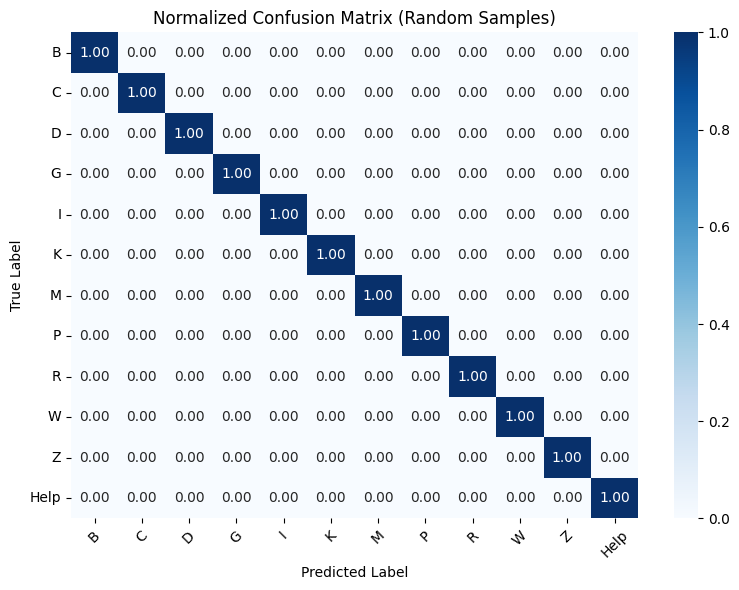

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split  # <--- add this
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Dataset & settings
DATA_PATH = "ASL Data"
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

actions = np.array([
    'A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S',
    'T','U','V','W','X','Y','Z','Hello','Help','Yes','No','ThankYou'
])

# Load dataset
def load_dataset():
    sequences = []
    labels = []
    for i, action in enumerate(actions):
        for seq in range(30):
            seq_path = f"{DATA_PATH}/{action}/{seq}"
            window = []
            for fnum in range(30):
                fpath = f"{seq_path}/{fnum}.npy"
                if os.path.exists(fpath):
                    window.append(np.load(fpath))
                else:
                    window.append(np.zeros((126,)))
            sequences.append(window)
            labels.append(i)
    X = np.array(sequences).astype(np.float32)
    y = tf.keras.utils.to_categorical(labels, num_classes=len(actions))
    return X, y

X, y = load_dataset()
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.05, shuffle=True, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.10, shuffle=True, random_state=SEED)

# Normalise
mu = X_train.mean()
sigma = X_train.std() + 1e-9

X_train = (X_train - mu) / sigma
X_val   = (X_val - mu) / sigma
X_test  = (X_test - mu) / sigma

# Add channel dimension for Conv1D
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]


# Custom layers for loading model
class ECA(tf.keras.layers.Layer):
    def __init__(self, kernel_size=5, **kwargs):
        super().__init__(**kwargs)
        self.conv = tf.keras.layers.Conv1D(1, kernel_size, padding='same', use_bias=False)
    def call(self, x):
        w = tf.reduce_mean(x, axis=1, keepdims=True)
        w = tf.transpose(w, perm=[0,2,1])
        w = self.conv(w)
        w = tf.transpose(w, perm=[0,2,1])
        w = tf.nn.sigmoid(w)
        return x * w

class LateDropout(tf.keras.layers.Layer):
    def __init__(self, rate=0.8, **kwargs):
        super().__init__(**kwargs)
        self.dropout = tf.keras.layers.Dropout(rate)
    def call(self, x, training=False):
        return self.dropout(x, training=training)

class CausalDWConv1D(tf.keras.layers.Layer):
    def __init__(self, k_size=17, dilation=1, **kwargs):
        super().__init__(**kwargs)
        self.pad = tf.keras.layers.ZeroPadding1D((dilation*(k_size-1),0))
        self.dw = tf.keras.layers.DepthwiseConv1D(k_size, dilation_rate=dilation, padding="valid", use_bias=False)
    def call(self, x): 
        return self.dw(self.pad(x))

def Conv1DBlock(out_ch, k_size, drop=0.2):
    def apply(x):
        in_ch = x.shape[-1]
        y = tf.keras.layers.Dense(in_ch*2, activation='swish')(x)
        y = CausalDWConv1D(k_size)(y)
        y = tf.keras.layers.BatchNormalization(momentum=0.95)(y)
        y = ECA()(y)
        y = tf.keras.layers.Dense(out_ch)(y)
        if drop:
            y = tf.keras.layers.Dropout(drop, noise_shape=(None,1,1))(y)
        return tf.keras.layers.Add()([x,y]) if in_ch == out_ch else y
    return apply

def TransformerBlock(dim, heads=4, expand=4, drop=0.2):
    def apply(x):
        y = tf.keras.layers.LayerNormalization()(x)
        y = tf.keras.layers.MultiHeadAttention(num_heads=heads, key_dim=dim, dropout=drop)(y,y)
        y = tf.keras.layers.Dropout(drop)(y)
        x = tf.keras.layers.Add()([x,y])
        y = tf.keras.layers.LayerNormalization()(x)
        y = tf.keras.layers.Dense(dim*expand, activation='swish')(y)
        y = tf.keras.layers.Dense(dim)(y)
        y = tf.keras.layers.Dropout(drop)(y)
        return tf.keras.layers.Add()([x,y])
    return apply

# Load trained model
model = load_model("cnntransformer_model.h5", custom_objects={
    "ECA": ECA,
    "LateDropout": LateDropout,
    "CausalDWConv1D": CausalDWConv1D,
    "Conv1DBlock": Conv1DBlock,
    "TransformerBlock": TransformerBlock
})

import time

# Inference time
start = time.time()
y_pred_prob = model.predict(X_test, batch_size=32, verbose=0)
end = time.time()
avg_infer_ms = (end - start) / len(X_test) * 1000

# Convert to class indexes
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Metrics
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"Avg inference time per sample: {avg_infer_ms:.2f} ms")

# Detailed class report
print("\nDetailed class report:")
print(classification_report(
    y_true, y_pred,
    labels=np.arange(len(actions)),
    target_names=actions,
    zero_division=0
))


# Confusion Matrix
rng = np.random.default_rng()  
sample_indices = rng.choice(len(X_test), size=15, replace=False)
X_sample = X_test[sample_indices]
y_sample = y_test[sample_indices]

# Predict on the sample
y_pred_sample_prob = model.predict(X_sample, verbose=0)
y_pred_sample = np.argmax(y_pred_sample_prob, axis=1)
y_true_sample = np.argmax(y_sample, axis=1)

# Only keep classes that appear in this sample
unique_classes = np.unique(np.concatenate([y_true_sample, y_pred_sample]))
sample_actions = actions[unique_classes]

# Compute confusion matrix
cm_sample = confusion_matrix(y_true_sample, y_pred_sample, labels=unique_classes)

# Normalize for better visualization
cm_sample_norm = cm_sample.astype('float') / cm_sample.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_sample_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=sample_actions, yticklabels=sample_actions)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix (Random Samples)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import time
from collections import deque
import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dropout, Dense, BatchNormalization, Add

# Settings
SEQ_LEN = 30
FEATURES = 126
MODEL_PATH = "cnntransformer_model.h5"
STATS_PATH = "cnntransformer_norm_stats.npz"

ACTIONS = np.array([
    'A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R',
    'S','T','U','V','W','X','Y','Z','Hello','Help','Yes','No','ThankYou'
], dtype=str)


# Custom Layers
class ECA(Layer):
    def __init__(self, kernel_size=5, **kwargs):
        super().__init__(**kwargs)
        self.conv = tf.keras.layers.Conv1D(1, kernel_size, padding='same', use_bias=False)
    def call(self, x):
        w = tf.reduce_mean(x, axis=1, keepdims=True)
        w = tf.transpose(w, perm=[0,2,1])
        w = self.conv(w)
        w = tf.transpose(w, perm=[0,2,1])
        w = tf.nn.sigmoid(w)
        return x * w

class LateDropout(Layer):
    def __init__(self, rate=0.8, **kwargs):
        super().__init__(**kwargs)
        self.dropout = Dropout(rate)
    def call(self, x, training=False):
        return self.dropout(x, training=training)

class CausalDWConv1D(Layer):
    def __init__(self, k_size=17, dilation=1, **kwargs):
        super().__init__(**kwargs)
        self.pad = tf.keras.layers.ZeroPadding1D((dilation*(k_size-1),0))
        self.dw = tf.keras.layers.DepthwiseConv1D(k_size, dilation_rate=dilation, padding="valid", use_bias=False)
    def call(self, x): 
        return self.dw(self.pad(x))


# Load Model + Normalisation Stats
print("Loading CNN-Transformer model...")
custom_layers = {'ECA': ECA, 'LateDropout': LateDropout, 'CausalDWConv1D': CausalDWConv1D}

with tf.keras.utils.custom_object_scope(custom_layers):
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)

stats = np.load(STATS_PATH)
MU = stats["mu"].astype(np.float32)
SIGMA = stats["sigma"].astype(np.float32)


# Mediapipe Hands
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    model_complexity=0,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Extract Keypoints
def extract_keypoints(results):
    lh = np.zeros(63, dtype=np.float32)
    rh = np.zeros(63, dtype=np.float32)

    if results.multi_hand_landmarks:
        for idx, hand in enumerate(results.multi_hand_landmarks):
            kp = np.array([[lm.x, lm.y, lm.z] for lm in hand.landmark], dtype=np.float32).flatten()
            handedness = results.multi_handedness[idx].classification[0].label
            if handedness == "Left":
                lh = kp
            else:
                rh = kp
    return np.concatenate([lh, rh], axis=0)


# Real-Time Prediction (live camera)
%gui qt

cap = cv2.VideoCapture(0)
seq = deque(maxlen=SEQ_LEN)

print("Real-time prediction started... Press 'q' to exit.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = hands.process(image)
    image.flags.writeable = True

    draw_frame = frame.copy()

    # Draw landmarks
    if results.multi_hand_landmarks:
        for hand in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                draw_frame, hand, mp_hands.HAND_CONNECTIONS,
                mp_drawing.DrawingSpec(color=(109, 33, 146), thickness=2, circle_radius=4),
                mp_drawing.DrawingSpec(color=(187,104,229), thickness=2, circle_radius=4),
            )

    # Extract 126 keypoints
    kp = extract_keypoints(results)
    seq.append(kp)

    display_text = ""
    info_text = ""

    # Predict only if sequence full
    if len(seq) == SEQ_LEN:
        x = np.array(seq, dtype=np.float32)

        # Normalize
        x = (x - MU) / SIGMA
        x = x[np.newaxis, ...]              

        # Inference
        t0 = time.time()
        logits = model.predict(x, verbose=0)
        infer_ms = (time.time() - t0) * 1000

        prob = logits[0]
        idx = int(np.argmax(prob))
        conf = float(prob[idx])

        display_text = ACTIONS[idx]
        info_text = f"Conf: {conf*100:.1f}% | {infer_ms:.1f} ms"

    # UI
    cv2.rectangle(draw_frame, (0, 0), (640, 60), (0, 0, 0), -1)
    cv2.putText(draw_frame, display_text, (10, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2)
    cv2.putText(draw_frame, info_text, (10, 55),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (100,255,100), 2)

    cv2.imshow("Real-Time Sign Language Recognition (CNN-TRANSFORMER)", draw_frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
hands.close()
cv2.destroyAllWindows()
print("Bye!")


Loading CNN-Transformer model...


I0000 00:00:1763554868.155704  902043 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 88), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1763554868.163074  902386 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763554868.165792  902381 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Real-time prediction started... Press 'q' to exit.


W0000 00:00:1763554876.227879  902384 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Bye!
